In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from churn.stats import cramers_v, theils_u, theil_matrix, cramer_matrix

In [2]:
# Load the entire Parquet file into a DataFrame
df = pd.read_parquet("../data/interim/telco_customer_churn_interim.parquet")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Bivariate/Multivariate Analysis

### MonthlyCharges and TotalCharges

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

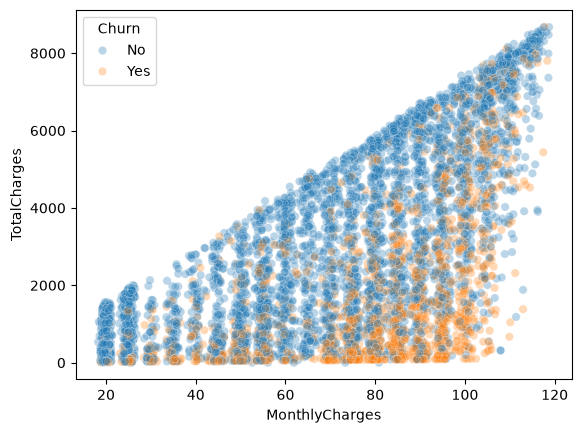

In [3]:
sns.scatterplot(data=df, x="MonthlyCharges", y="TotalCharges", hue="Churn",alpha=0.3)

1. A triangle or wedge shape.

* Every point sits below a rising diagonal edge. That edge is about 72 × `MonthlyCharges`, and 72 months is the maximum `tenure`. At a monthly charge of 118 the ceiling is about 8,500, which matches the top-right corner.
* `TotalCharges` ≈ `MonthlyCharges` × `tenure`, so this feature is mostly derived from the other two. A customer's position in the wedge is set by `tenure`: near the bottom means new, near the top edge means a long-standing customer.
* The points sitting at about `0` are the `tenure == 0` customers, whose blank `TotalCharges` was filled with `0`.

2. A fan shape. At low MonthlyCharges the vertical spread is narrow, and it widens as MonthlyCharges rises. The reason is that the same monthly price can belong to a 2-month customer or a 70-month customer. The higher the price, the larger the range of totals that tenure can produce.

3. Churn (orange) is not evenly spread. It piles up in the lower-right: high monthly charge and low total charge. That means short tenure combined with an expensive plan, such as new fibre-optic customers. The top of the wedge, long tenure, is mostly blue. Since the churner is plotted over the retained customers, the density of orange in the lower-right is probably understated.


A dense cluster near MonthlyCharges ≈ 20-30. These are phone-only customers with no internet service, which is the cheapest tier. They are mostly blue (retained) and spread across all tenures.


<Axes: xlabel='PhoneService', ylabel='MonthlyCharges'>

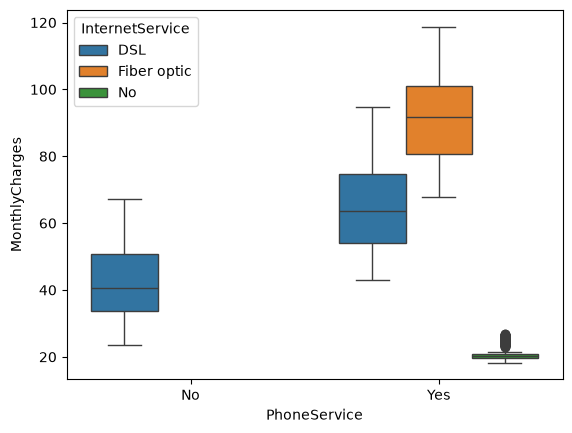

In [4]:
sns.boxplot(data=df, x="PhoneService", y="MonthlyCharges", hue="InternetService")

In [5]:
temp_df = df.loc[df['MonthlyCharges']<=30, ['PhoneService', 'InternetService', 'MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']].copy()

In [6]:
pd.crosstab(temp_df['PhoneService'], temp_df['InternetService'])

InternetService,DSL,No
PhoneService,,
No,127,0
Yes,0,1526


In [7]:
# Calculate between two specific columns
cov_pair = df['MonthlyCharges'].cov(df['TotalCharges'])
corr_pair = df['MonthlyCharges'].corr(df['TotalCharges'])
print(f"Pairwise Covariance: {cov_pair}")
print(f"Pairwise Correlation: {corr_pair}")

Pairwise Covariance: 44415.23367830183
Pairwise Correlation: 0.651173831578784


Correlation of 0.65. This is clearly positive but not near 1. If tenure were fixed, the two would be perfectly linked. Tenure varies from 0 to 72, and that is what loosens the relationship.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

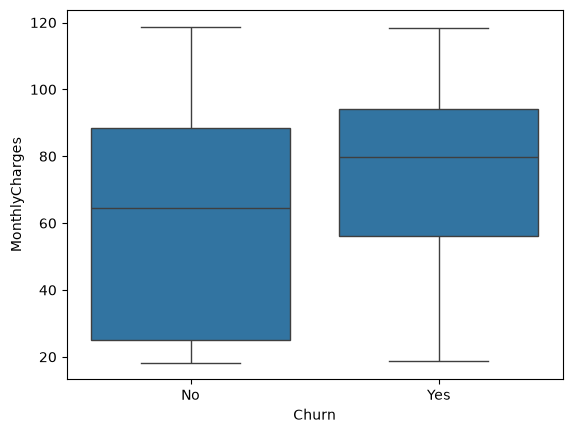

In [8]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

<Axes: xlabel='Churn', ylabel='TotalCharges'>

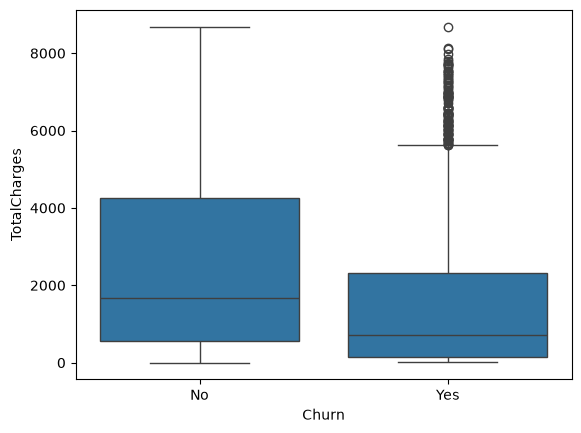

In [9]:
sns.boxplot(data=df, x="Churn", y="TotalCharges")

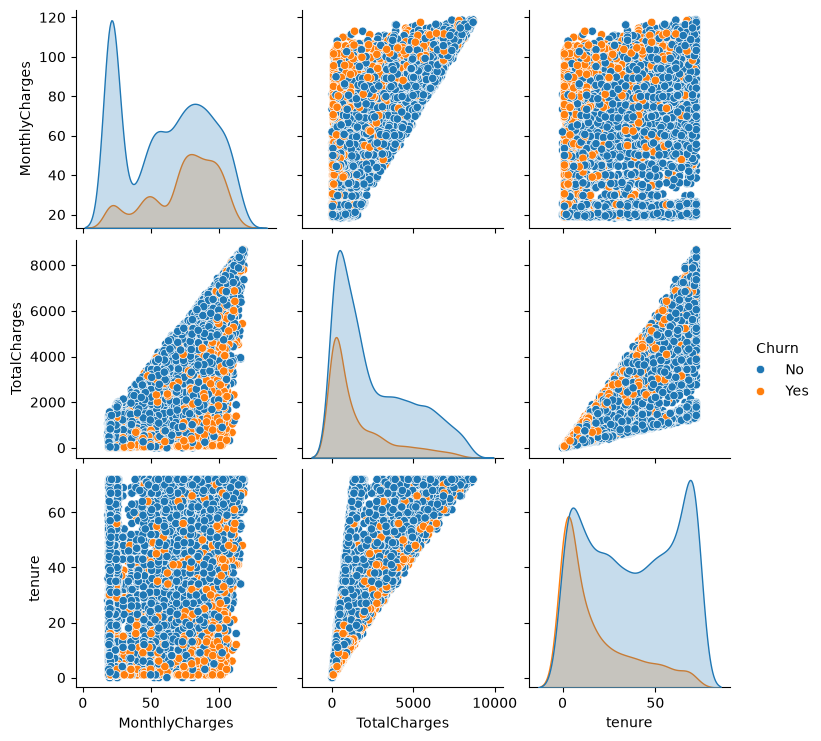

In [10]:
sns.pairplot(df, hue="Churn", vars=["MonthlyCharges", "TotalCharges", "tenure"])

On checking `MonthlyCharges` vs `tenure`, churn is higher for high `MonthlyCharges` and low  `tenure`.

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges_per_month'>

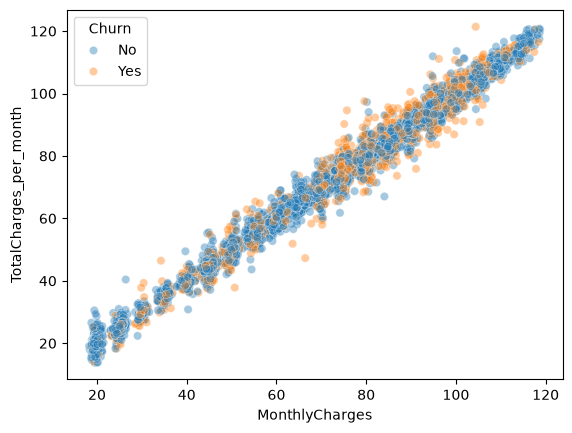

In [11]:
temp_df = df.loc[df['tenure']>0, ['MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']].copy()
temp_df['TotalCharges_per_month'] = temp_df['TotalCharges'] / temp_df['tenure']
sns.scatterplot(data=temp_df, x="MonthlyCharges", y="TotalCharges_per_month", hue="Churn", alpha=0.4)


In [12]:
temp_df['MonthlyCharges'].corr(temp_df['TotalCharges_per_month'])

np.float64(0.9962373123907751)

Good correlation between `MonthlyCharges` and `TotalCharges_per_month`

<Axes: xlabel='MonthlyCharges', ylabel='tenure'>

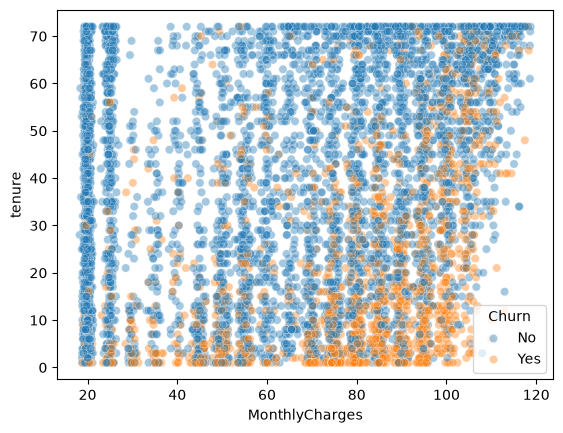

In [13]:
sns.scatterplot(data=temp_df, x="MonthlyCharges", y="tenure", hue="Churn", alpha=0.4)

> i have decided to remove the column `TotalCharges` and keep `MonthlyCharges` and `tenure` as these 2 columns covers the info in `TotalCharges` and the colinearlity is also taken care of in this way between `TotalCharges` and  `MonthlyCharges`.

In [14]:
df.drop(columns=['TotalCharges'], inplace=True, errors='ignore')

#### Bivariate Analysis of Categorical Features on Churn Rate

In [15]:
df.groupby(['Contract'])['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [16]:
df["Churn_num"] = (df["Churn"] == "Yes").astype(int)
overall = df["Churn_num"].mean()          # baseline, about 0.265

In [17]:
overall  ## baseline churn value

np.float64(0.2653698707936959)

In [18]:
# Check 1: churn rate + group size for one feature

summary = (
    df.groupby("Contract")["Churn_num"]
      .agg(churn_rate="mean", n="count")
      .sort_values("churn_rate", ascending=False)
)

# summary
# The mean of a 1/0 column is the proportion of 1s, so mean is the churn rate. n tells you how much evidence is behind each rate.

In [19]:
summary

,churn_rate,n
Contract,,
Month-to-month,0.427097,3875
One year,0.112695,1473
Two year,0.028319,1695


By grouping the data by specific categorical columns and taking the mean of this binary column `Churn`, you derive the exact churn proportion for each subgroup.

In [20]:
# Check 2: plot against the baseline

def plot_churn_rate(col, data=df):
    order = data.groupby(col)["Churn_num"].mean().sort_values(ascending=False).index
    ax = sns.barplot(data=data, x=col, y="Churn_num", order=order)   # bars = mean, whiskers = 95% CI
    ax.axhline(overall, color="red", linestyle="--", label=f"overall {overall:.1%}")
    ax.set_ylabel("Churn rate")
    ax.legend()
    plt.xticks(rotation=20)
    plt.show()

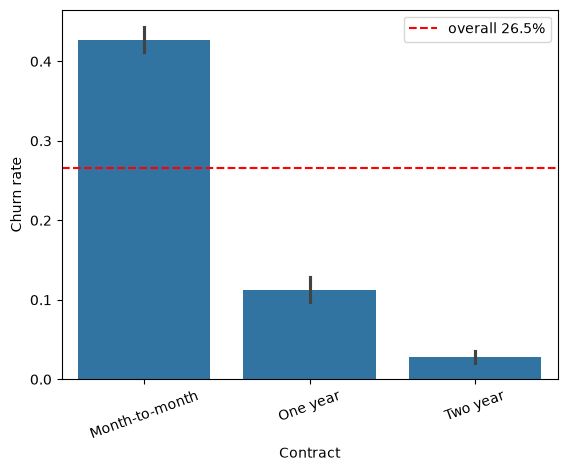

In [21]:
plot_churn_rate("Contract")

In [22]:
cat_cols = [c for c in df.select_dtypes(exclude="number").columns
            if c not in ("customerID", "Churn")] + ["SeniorCitizen"]

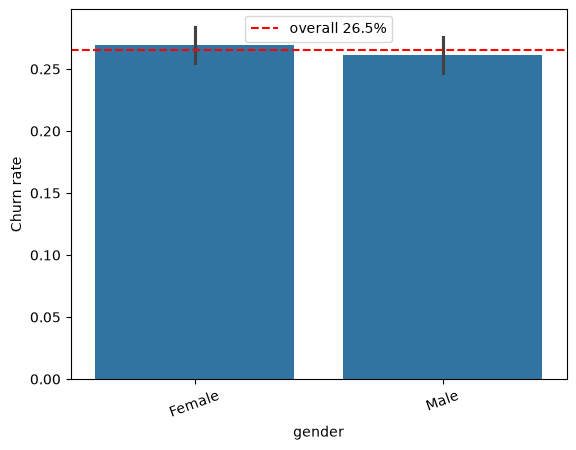

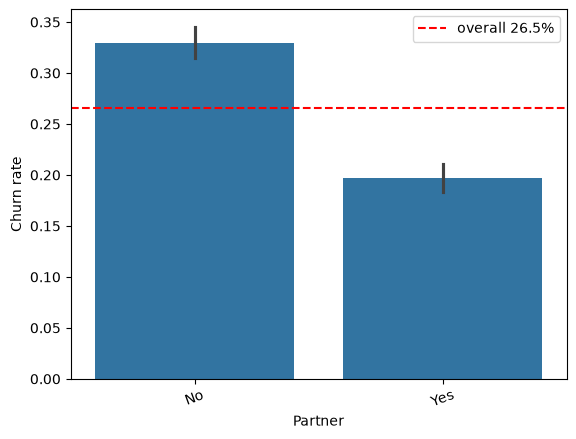

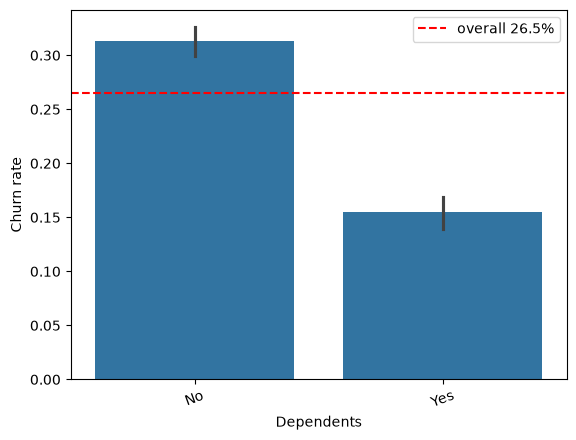

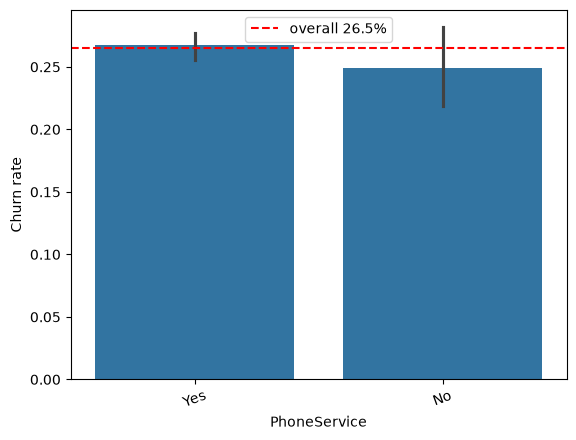

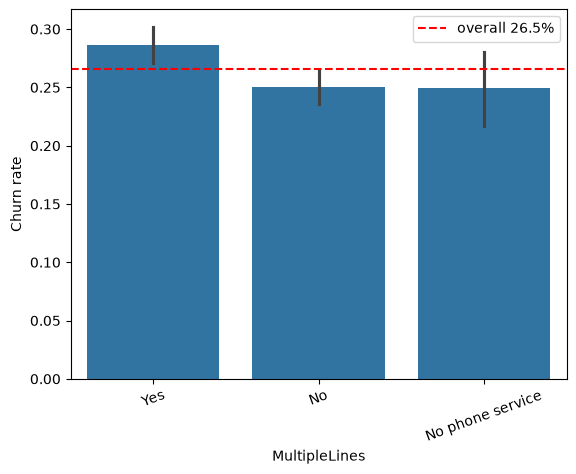

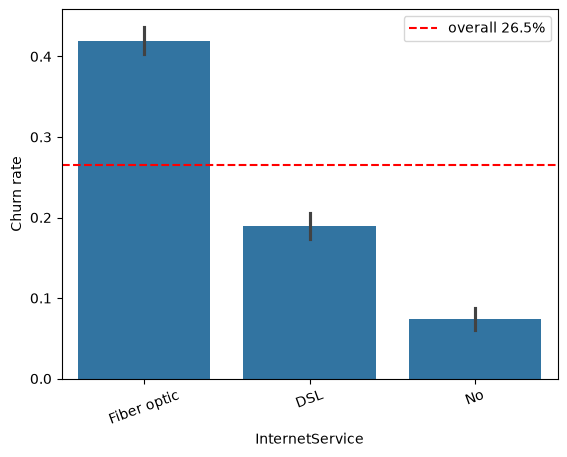

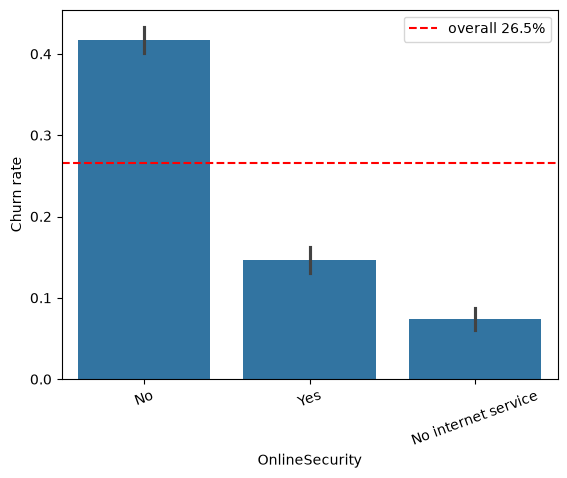

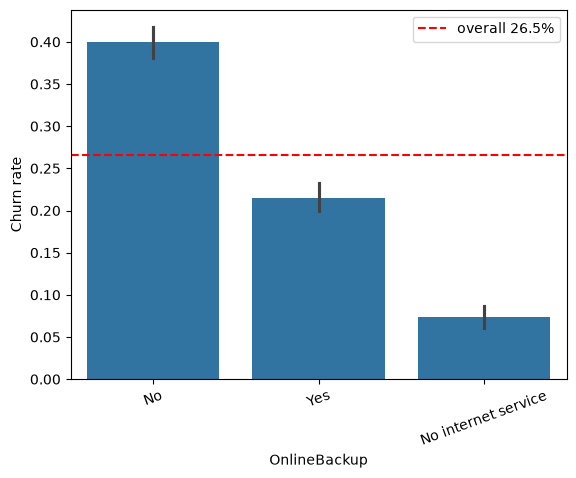

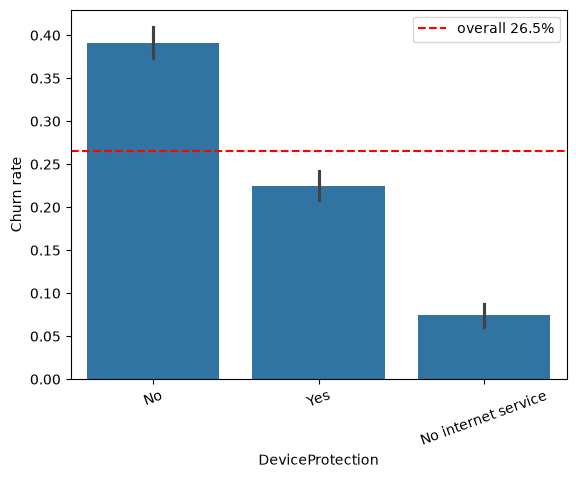

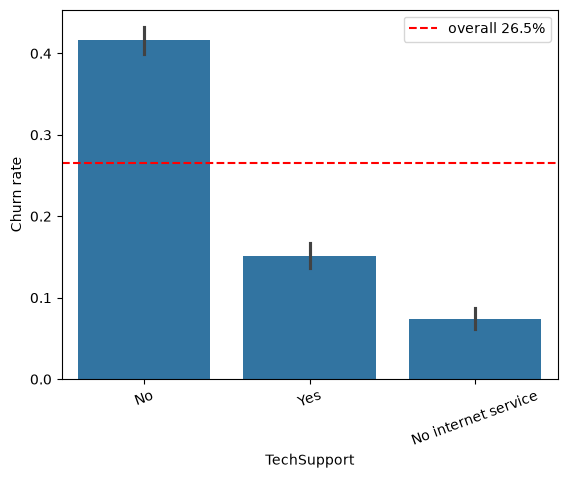

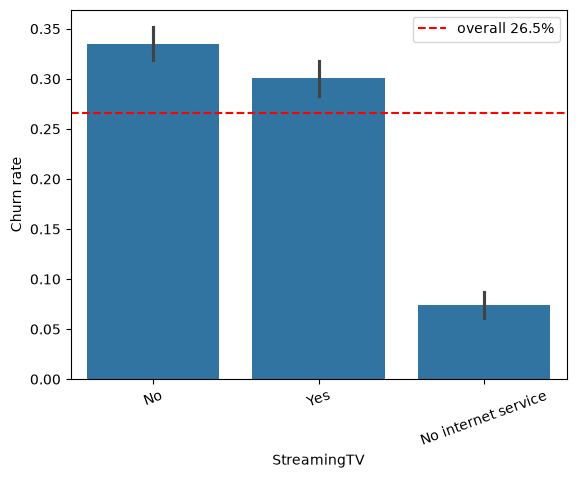

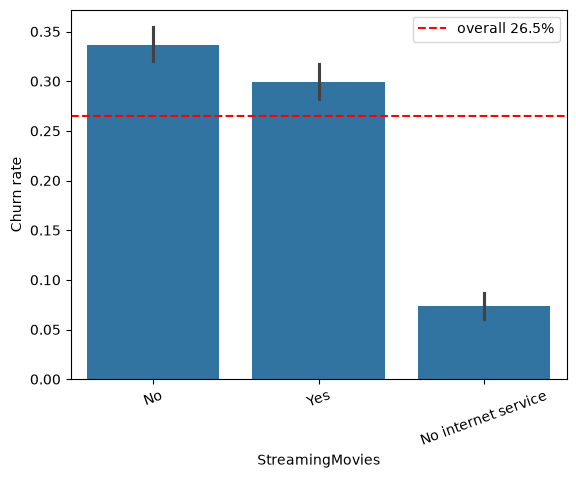

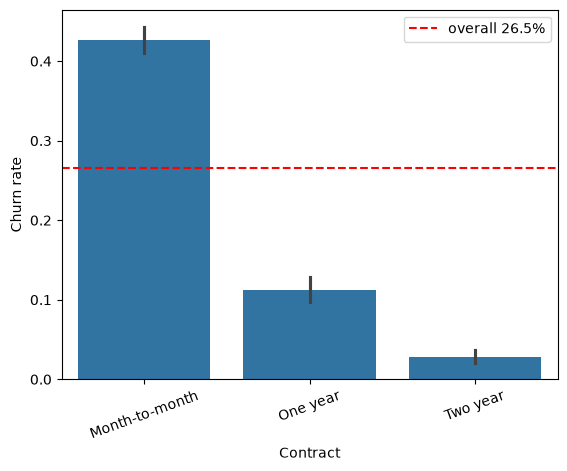

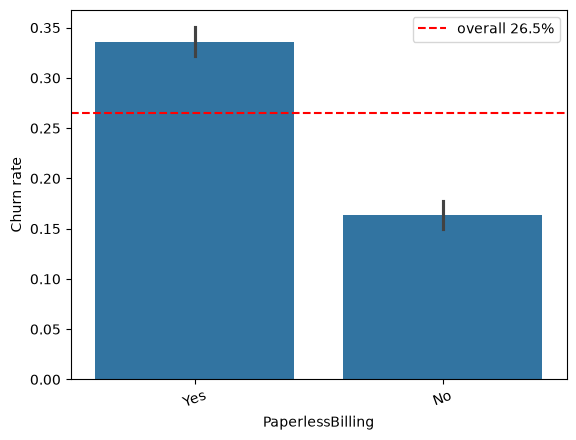

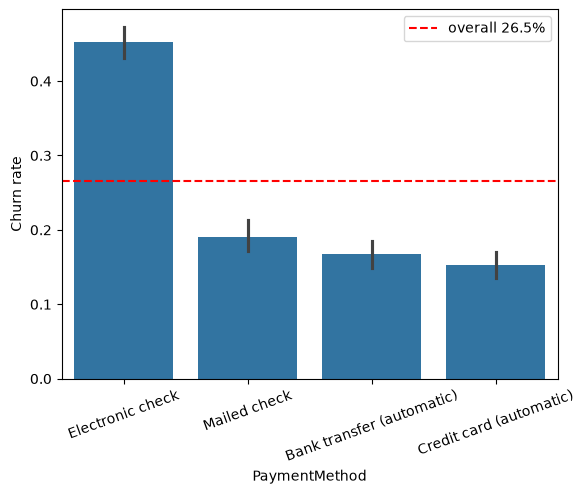

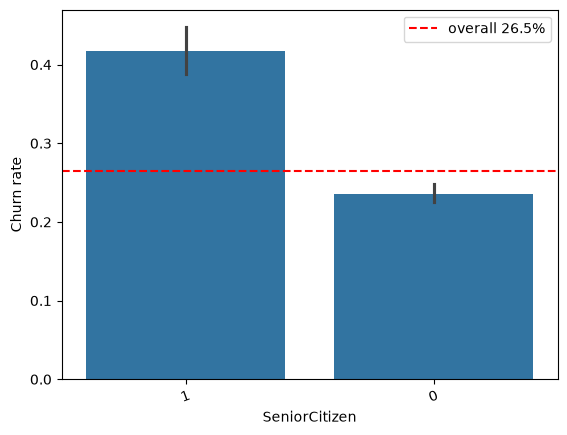

In [23]:
for col in cat_cols:
    plot_churn_rate(col)

You interpret these graphs by looking at the vertical distance between the top of each bar and the red dashed baseline. The red line represents the "average" customer; the bars show how specific subgroups deviate from that average.

**Maximum Impact (High Predictive Signal)**
A categorical feature has a massive impact on churn when you see wild variation in the heights of its bars.

* **Visual Cue:** You will see a "staircase" effect or drastic peaks and valleys. Some categories will tower above the red line, while others will sit far below it.
* **What it Means:** The feature strongly separates customer behavior. Knowing which category a customer falls into drastically changes their probability of churning compared to a blind guess.
* **Example:** In a `Contract` graph, a "Month-to-month" bar might spike to 42% (way above the 26.5% baseline), while the "Two-year" bar drops to 3%. This massive gap means `Contract` is a highly valuable predictor for your model.

**Least Impact (Low Predictive Signal)**
A feature has little to no impact when all of its categories behave exactly like the overall average.

* **Visual Cue:** The "flatline." Every bar in the chart stops right at or very near the red dashed baseline.
* **What it Means:** The feature is essentially noise. Knowing this specific customer detail gives you no new mathematical leverage to predict if they will leave.
* **Example:** In a `Gender` graph, if the "Male" bar sits at 26.2% and the "Female" bar sits at 26.8%, both are practically touching the baseline. Dropping this column from your dataset entirely will likely improve model performance by removing dead weight.

## Bivariate Analysis Methodology

The provided code calculates the baseline churn rate at approximately 26.5% by converting the categorical "Yes"/"No" target into a binary 1/0 variable. By grouping the data by specific categorical columns and taking the mean of this binary column, you derive the exact churn proportion for each subgroup. The sample size (`n`) dictates the statistical confidence of that specific rate.

## Categorical Feature Impacts

Based on the structure of the Telco Customer Churn dataset, here is how the primary categorical columns impact customer retention:

* **Contract**: This is traditionally the strongest predictor. Your code output demonstrates that Month-to-month contracts have a high churn rate of 42.7%, whereas One-year (11.2%) and Two-year (2.8%) contracts retain customers successfully.


* **InternetService**: Customers with Fiber Optic service generally show much higher churn compared to DSL or No Internet. This often indicates pricing sensitivity or regional service reliability issues.
* **PaymentMethod**: Users paying via Electronic Check churn at drastically higher rates than those relying on automated methods like Credit Card or Bank Transfer. Manual payment friction strongly correlates with account cancellation.
* **Demographics (SeniorCitizen, Partner, Dependents)**: Customers flagged as Senior Citizens typically exhibit a higher churn probability. Conversely, customers with partners or dependents demonstrate lower churn, likely due to the logistical friction of migrating family households or multi-line plans.
* **Value-Added Services (TechSupport, OnlineSecurity)**: Customers lacking supplementary services like Tech Support, Online Security, Online Backup, or Device Protection are highly vulnerable to churn. Bundled services create ecosystem "stickiness."


In [24]:
v, p = cramers_v(df["Contract"], df["Churn"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.00000) < 0.05: Reject the Null Hypothesis. 'Contract' and 'Churn' are DEPENDENT.
Cramer's V: 0.4098, p-value: 0.0000


In [25]:
v, p = cramers_v( y=df["Churn"], x=df["Contract"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.00000) < 0.05: Reject the Null Hypothesis. 'Contract' and 'Churn' are DEPENDENT.
Cramer's V: 0.4098, p-value: 0.0000


In [26]:
cat_cols = [c for c in df.select_dtypes(exclude="number").columns
            if c not in ("customerID")] + ["SeniorCitizen"]
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

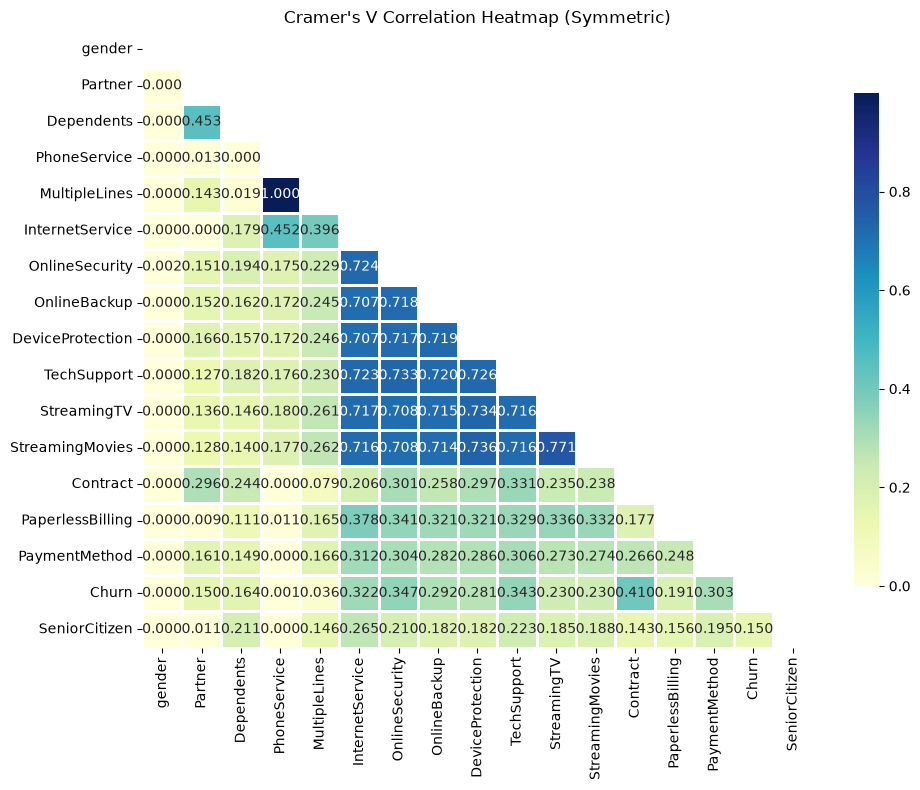

In [27]:
cramer_matrix(data=df, columns=cat_cols)

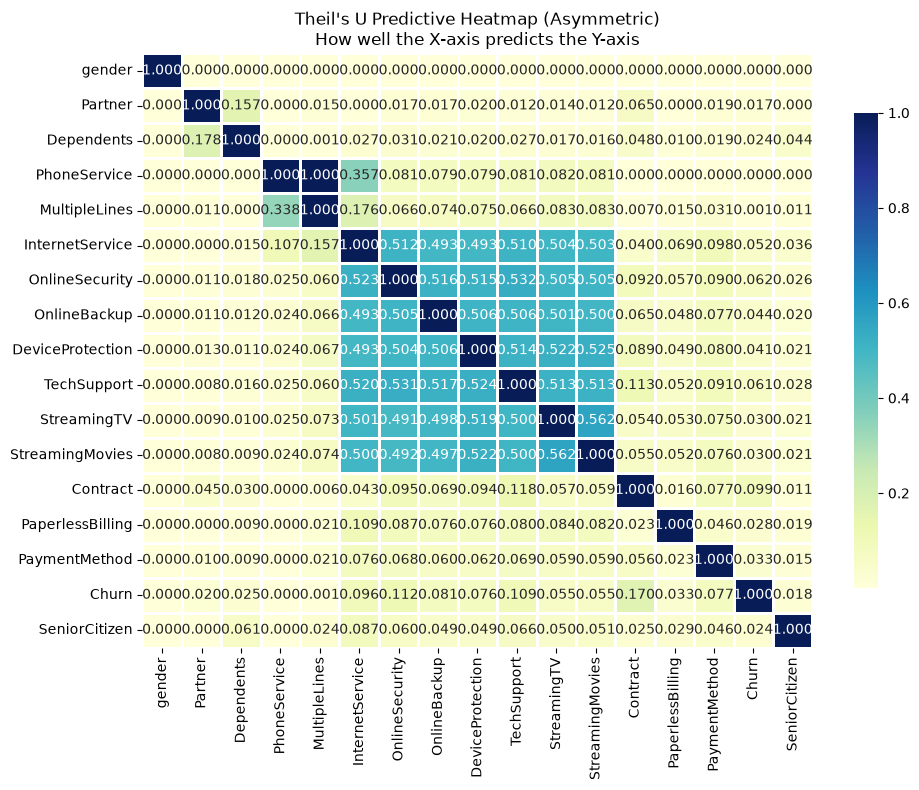

In [28]:
theil_matrix(data=df, columns=cat_cols)

## Check Streming TV and Streaming Movie Services


<Axes: xlabel='StreamingTV', ylabel='Count'>

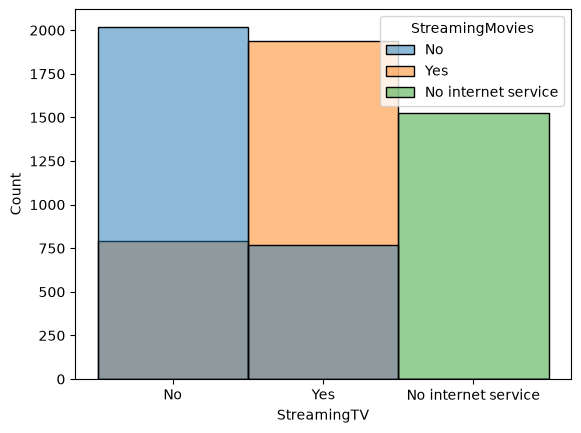

In [31]:
sns.histplot(df, x='StreamingTV', hue='StreamingMovies')

In [ ]:
v, p = cramers_v( y=df["StreamingTV"], x=df["StreamingMovies"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.00000) < 0.05: Reject the Null Hypothesis. 'StreamingMovies' and 'StreamingTV' are DEPENDENT.
Cramer's V: 0.7710, p-value: 0.0000


In [ ]:
theils_u(y=df["StreamingTV"], x=df["StreamingMovies"])  

np.float64(0.5623841367162747)

The "No Internet Service" is same in both `StreamingTV` and `StreamingMovies`. 

### Relationship between `StreamingTV` and `StreamingMovies`

Because both features are categorical, a normalized heatmap is more informative than a scatterplot. Each cell shows the percentage of customers in a `StreamingTV` category who fall into each `StreamingMovies` category. This makes the pattern easier to compare despite differences in category sizes.


In [34]:
pd.crosstab( df["StreamingTV"], df["StreamingMovies"] )

StreamingMovies,No,No internet service,Yes
StreamingTV,,,
No,2018,0,792
No internet service,0,1526,0
Yes,767,0,1940


The 1,526 "No internet service" customers match in both columns automatically, and that inflates Cramer-V of 0.77.

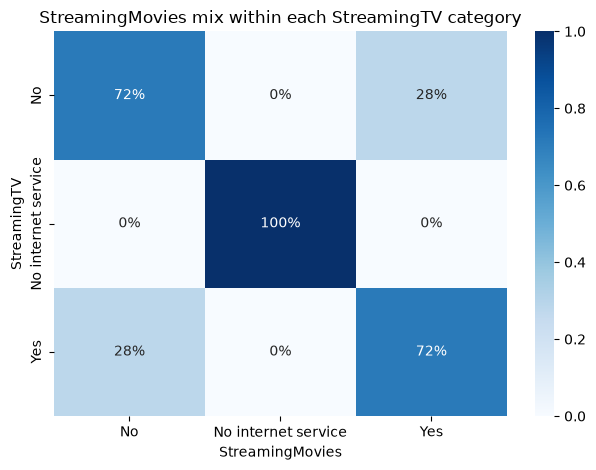

In [32]:
streaming_mix = pd.crosstab(
    df["StreamingTV"],
    df["StreamingMovies"],
    normalize="index"
)

sns.heatmap(streaming_mix, annot=True, fmt=".0%", cmap="Blues")
plt.xlabel("StreamingMovies")
plt.ylabel("StreamingTV")
plt.title("StreamingMovies mix within each StreamingTV category")
plt.tight_layout()

In [35]:
inet = df[df["InternetService"] != "No"]

v, p = cramers_v(x=inet["StreamingMovies"], y=inet["StreamingTV"])
print(f"V (internet customers only): {v:.3f}")
print("U(TV | Movies):", theils_u(x=inet["StreamingMovies"], y=inet["StreamingTV"]))
print("U(Movies | TV):", theils_u(x=inet["StreamingTV"], y=inet["StreamingMovies"]))

p-value (0.00000) < 0.05: Reject the Null Hypothesis. 'StreamingMovies' and 'StreamingTV' are DEPENDENT.
V (internet customers only): 0.435
U(TV | Movies): 0.14102689427898524
U(Movies | TV): 0.14100082098234062


A large drop means most of the redundancy came from the shared level, not from the services themselves.

In [36]:
pd.crosstab(inet["StreamingTV"], inet["StreamingMovies"], margins=True)

StreamingMovies,No,Yes,All
StreamingTV,,,
No,2018,792,2810
Yes,767,1940,2707
All,2785,2732,5517


Look at the off-diagonal cells: TV=Yes with Movies=No, and TV=No with Movies=Yes. If a large share of internet customers sit there, the columns describe different customers and aren't duplicate.

##### Does Movies change churn once you know TV?
Build a combined column and use your plot_churn_rate function:

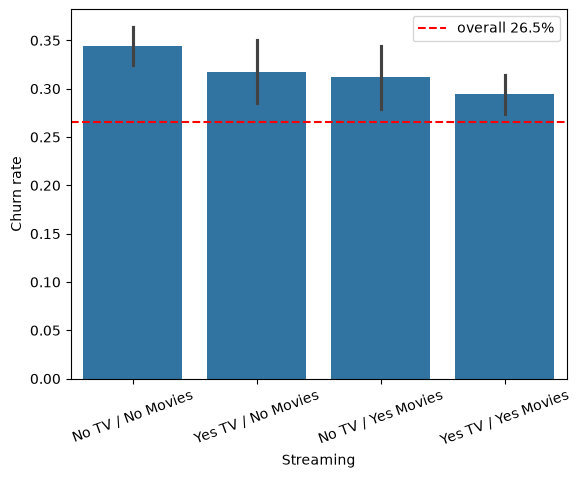

In [37]:
inet = inet.assign(Streaming=inet["StreamingTV"] + " TV / " + inet["StreamingMovies"] + " Movies")
plot_churn_rate("Streaming", data=inet)

In [39]:
inet.shape

(5517, 22)

In [40]:
inet['Streaming'].value_counts()

Streaming
No TV / No Movies      2018
Yes TV / Yes Movies    1940
No TV / Yes Movies      792
Yes TV / No Movies      767
Name: count, dtype: int64

In [41]:
print("U(Churn | TV):        ", theils_u(x=inet["StreamingTV"], y=inet["Churn"]))
print("U(Churn | Movies): ", theils_u(x=inet["StreamingMovies"],   y=inet["Churn"]))
print("U(Churn | TV+Movies): ", theils_u(x=inet["Streaming"],   y=inet["Churn"]))

U(Churn | TV):         0.0010983847099161877
U(Churn | Movies):  0.0012881165726641233
U(Churn | TV+Movies):  0.001683026744297414


Adding Movies to TV gains about 0.0006, and part of that is the inflation you'd expect from a column with more categories. That's negligible.  

Everything sits in the 29–34% range you saw, right around the internet-customer average. So the decision barely matters for model performance, and that's another reason to keep the simpler option.

Decided to drop `StreamingMovies` it adds almost nothing about churn beyond what StreamingTV already tells. 

 

### Check Gender

based on the churn_rate baseline, `Gender` both sit on the baseline and have no imapct on Churn.

Theil-U and Cramer-V also show that these 2 are independent so `gender` column can be dropped from the analysis.

In [42]:
v, p = cramers_v( y=df["Churn"], x=df["gender"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.46983) >= 0.05: Fail to reject the Null Hypothesis. 'gender' and 'Churn' are INDEPENDENT.
Cramer's V: 0.0000, p-value: 0.4698


In [43]:
theils_u(y=df["Churn"], x=df["gender"])  

np.float64(6.409086889696102e-05)

Based on the above detail, decided to drop column `gender`.

#### Check `PhoneService` and `MultipleLines`

<Axes: xlabel='PhoneService', ylabel='Count'>

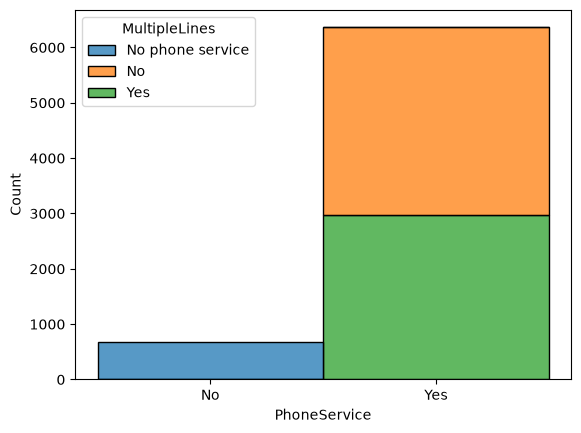

In [29]:
sns.histplot(df, x='PhoneService', hue='MultipleLines', multiple='stack')

`MultipleLines` has a level called "No phone service", so it already contains `PhoneService` exactly.

Both have simialr type of churn-rate basline.  Phone Service and Baseline are highly associated. So one of them can be dropped.

In [35]:
v, p = cramers_v( y=df["PhoneService"], x=df["MultipleLines"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.00000) < 0.05: Reject the Null Hypothesis. 'MultipleLines' and 'PhoneService' are DEPENDENT.
Cramer's V: 0.9999, p-value: 0.0000


In [36]:
theils_u(y=df["PhoneService"], x=df["MultipleLines"])  

np.float64(1.0)

In [37]:
theils_u(x=df["MultipleLines"],y=df["PhoneService"])  

np.float64(1.0)

In [38]:
v, p = cramers_v( y=df["Churn"], x=df["MultipleLines"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.00346) < 0.05: Reject the Null Hypothesis. 'MultipleLines' and 'Churn' are DEPENDENT.
Cramer's V: 0.0364, p-value: 0.0035


In [39]:
v, p = cramers_v( y=df["Churn"], x=df["PhoneService"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.31625) >= 0.05: Fail to reject the Null Hypothesis. 'PhoneService' and 'Churn' are INDEPENDENT.
Cramer's V: 0.0008, p-value: 0.3162


In [40]:
theils_u(y=df["Churn"], x=df["PhoneService"])  

np.float64(0.00012471416034482154)

In [41]:
theils_u(y=df["Churn"], x=df["MultipleLines"])  

np.float64(0.00138483788353745)

Based on the above studies, I have decided to drop `PhoneService`.

In [42]:
# df.drop(columns=['PhoneService'], inplace=True, errors='ignore')

In [43]:
df.columns

Index(['customerID', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn',
       'Churn_num'],
      dtype='str')

### SeniorCitizen

It has good theils_u value and cramers_v value so it can help in Churn prediction. Also the churn_rate bar graph is a stroung evidence.

In [44]:
v, p = cramers_v( y=df["Churn"], x=df["SeniorCitizen"])
print(f"Cramer's V: {v:.4f}, p-value: {p:.4f}")

p-value (0.00000) < 0.05: Reject the Null Hypothesis. 'SeniorCitizen' and 'Churn' are DEPENDENT.
Cramer's V: 0.1504, p-value: 0.0000


In [45]:
theils_u(y=df["Churn"], x=df["SeniorCitizen"])  

np.float64(0.018280818761022645)

#### Relationship between `OnlineSecurity` and `OnlineBackup`

In [53]:
pd.crosstab(df["OnlineSecurity"], df["OnlineBackup"])

OnlineBackup,No,No internet service,Yes
OnlineSecurity,,,
No,2195,0,1303
No internet service,0,1526,0
Yes,893,0,1126


<Axes: xlabel='OnlineBackup', ylabel='Count'>

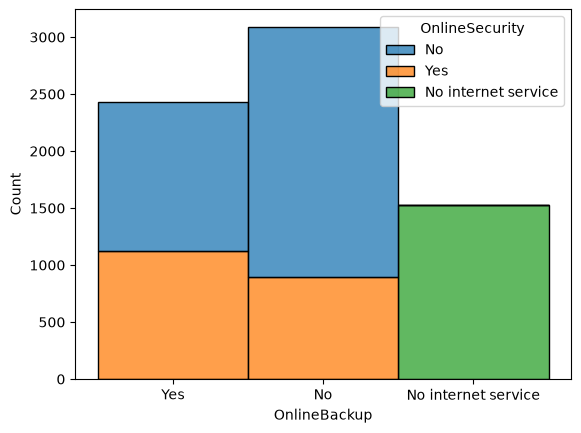

In [54]:
sns.histplot(df, hue='OnlineSecurity', x='OnlineBackup', multiple='stack')

So `OnlineSecurity` and `Onlinebackup` are seperate features shared with subscribers as those who dont have `OnlineSecurity` have `Onlinebackup` and vice-versa.

Similar such issues due to "No Internet Service" is available in other columns also.

### "No Internet Service" redundancy in multiple columns

And they have high associations but as shown in `StreamingTV` and `StreamingMovies` study its due to "No Internet Service" value.

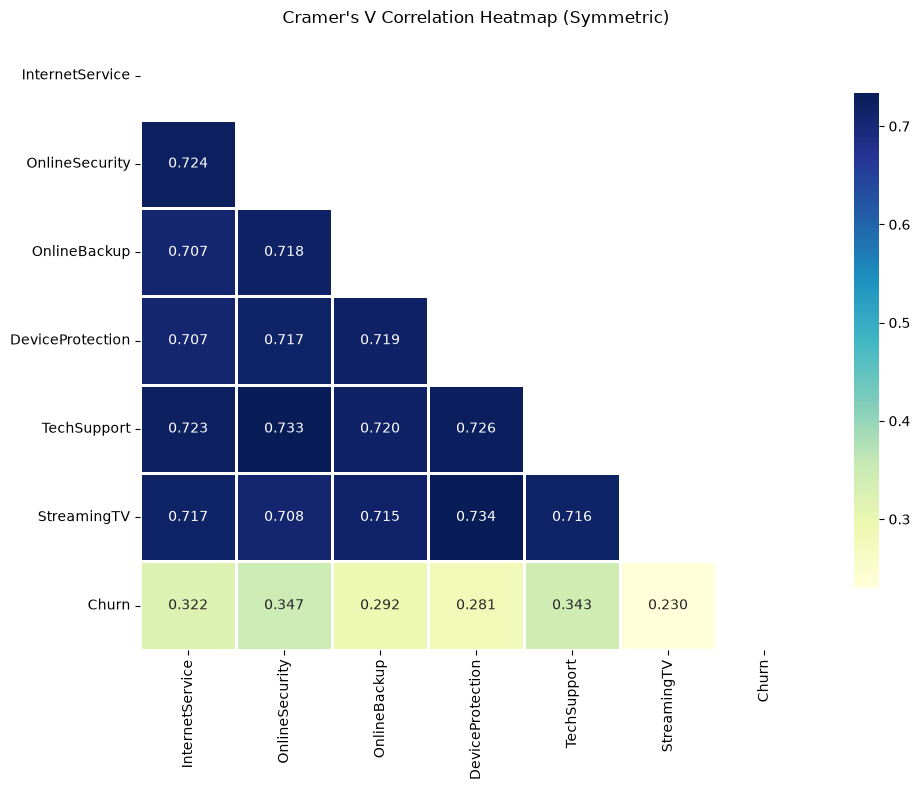

In [55]:
cramer_matrix(data=df, columns = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
 'DeviceProtection', 'TechSupport', 'StreamingTV', 'Churn']) 

In [46]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

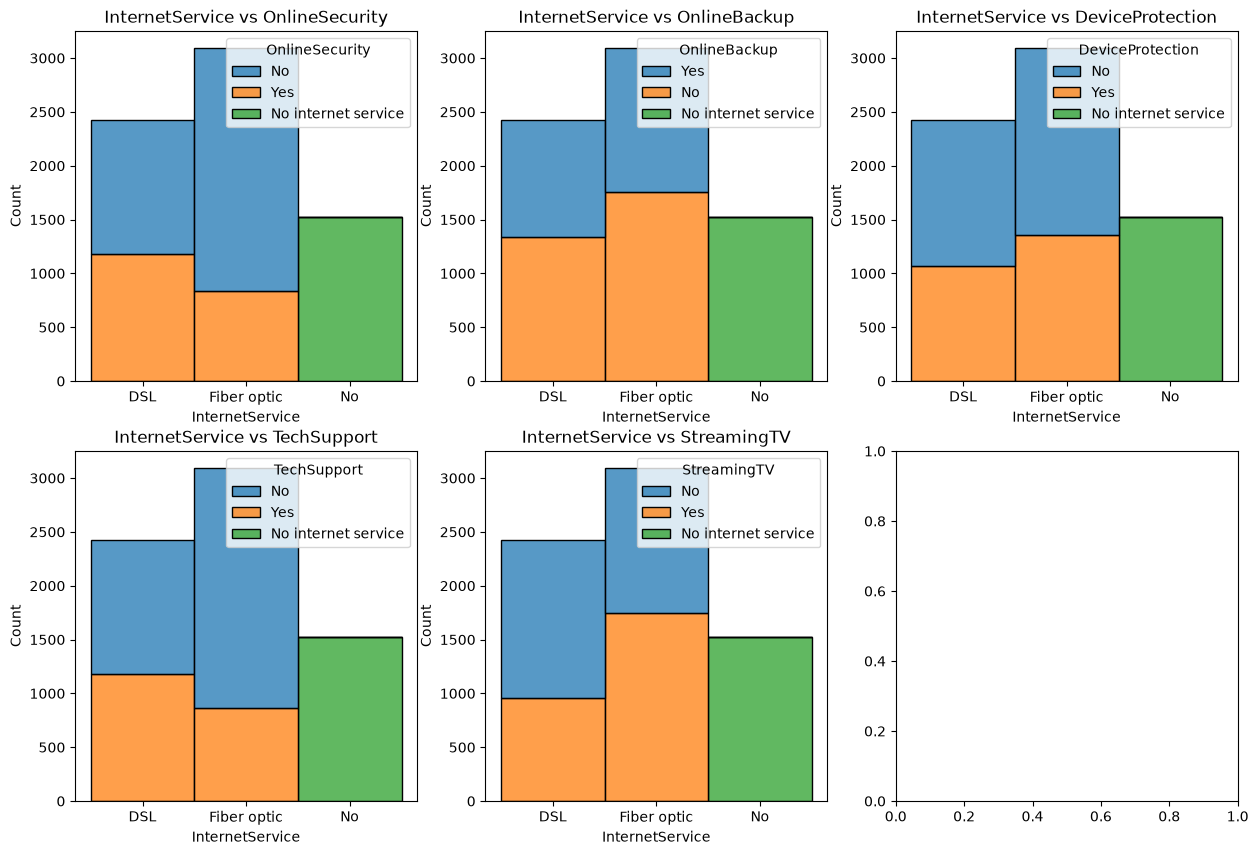

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(['OnlineSecurity', 'OnlineBackup',  'DeviceProtection', 'TechSupport', 'StreamingTV']):
    ax = axes[i//3, i%3]
    sns.histplot(df, hue=col, x='InternetService', multiple='stack', ax=ax)
    ax.set_title(f"InternetService vs {col}")

So the **No** in `InternetService` and **No Internet service** in the 5 other columns have the same count.

In [56]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV"]
no_inet = df["InternetService"] == "No"

for col in service_cols:
    print(col, ((df[col] == "No internet service") == no_inet).all())


OnlineSecurity True
OnlineBackup True
DeviceProtection True
TechSupport True
StreamingTV True


Replace "No internet service" with "No" in the 5 columns, so each becomes Yes/No. 

In [57]:
df[service_cols] = df[service_cols].replace("No internet service", "No")

Now check the change in Cramer V value.

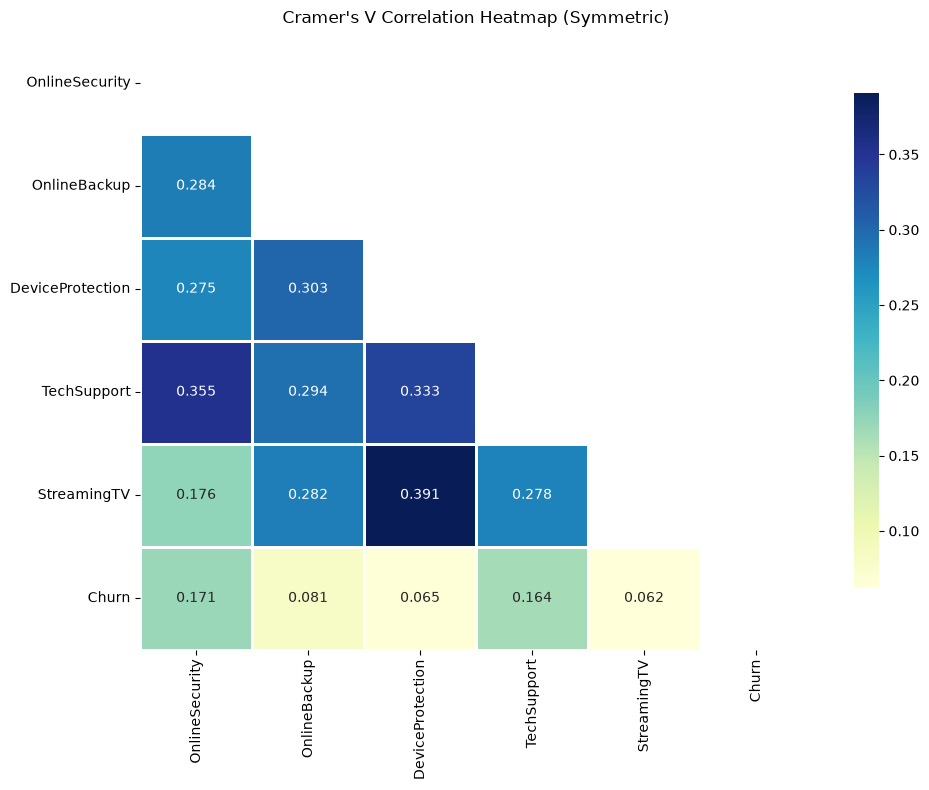

In [59]:
cramer_matrix(data=df, columns = [ 'OnlineSecurity', 'OnlineBackup',
 'DeviceProtection', 'TechSupport', 'StreamingTV', 'Churn']) 

In [68]:
y_col = ["Churn"] * len(service_cols)
x_col = []
u_col = []
for col in [ 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV']:
    x_col.append(col)
    u = theils_u(y=df["Churn"], x=df[col])
    u_col.append(u)

In [69]:
pd.DataFrame({"y_col": y_col, "x_col": x_col, "u_col": u_col}).sort_values("u_col", ascending=False)

,y_col,x_col,u_col
0,Churn,OnlineSecurity,0.027454
3,Churn,TechSupport,0.025248
1,Churn,OnlineBackup,0.005980
2,Churn,DeviceProtection,0.003850
4,Churn,StreamingTV,0.003424


They aren't redundant with each other. Cramér's V between any two of them is only 0.04–0.28. Once the shared "No internet service" level is gone, each says something different.  

`OnlineSecurity` and `TechSupport` are the strong ones and have good association with `Churn`.

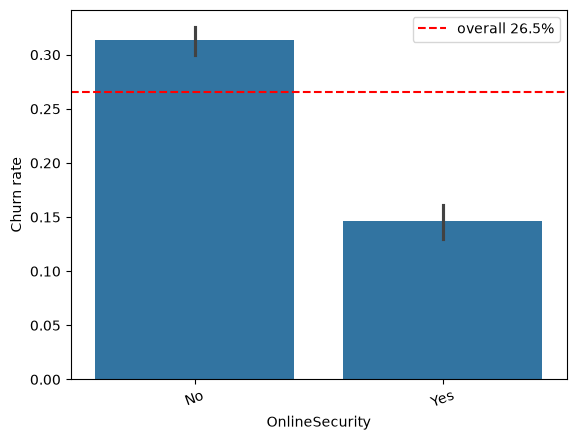

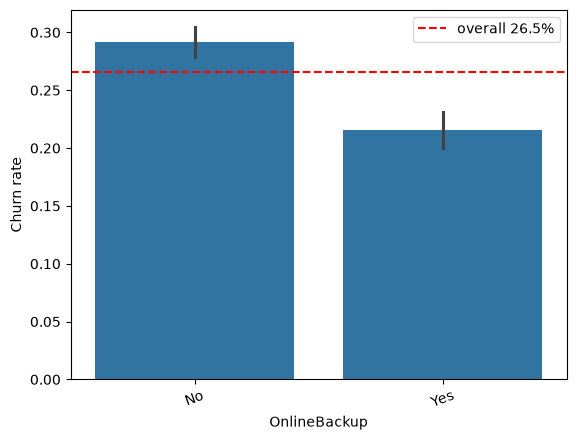

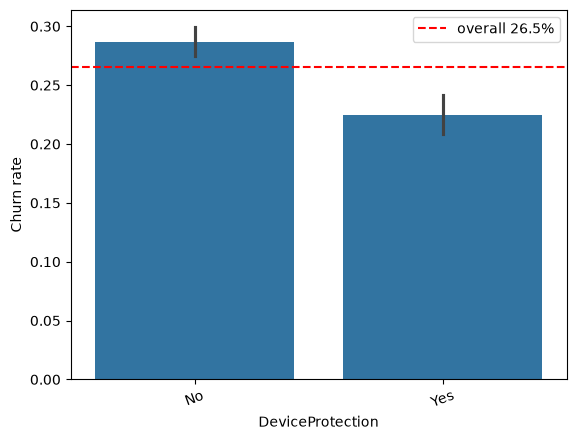

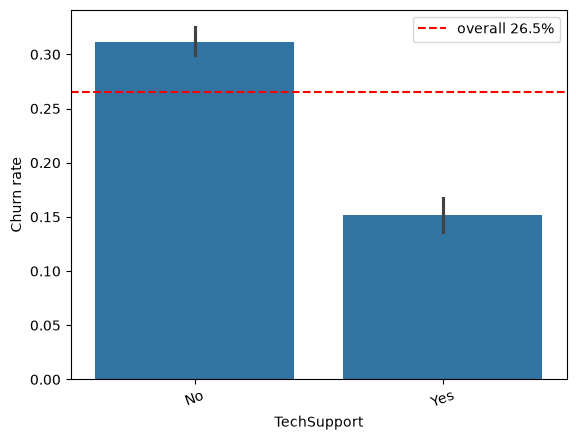

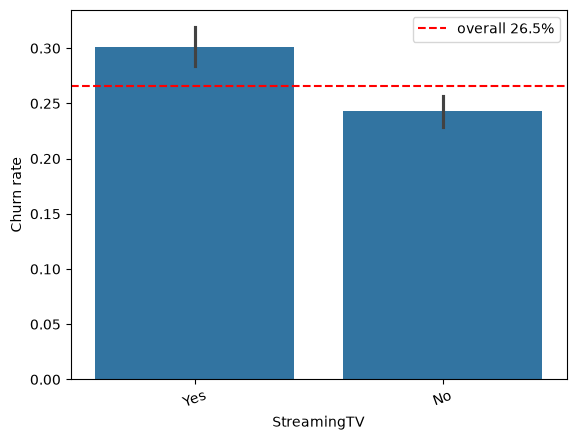

In [60]:
for col in [ 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV']:
    plot_churn_rate(col)

I will be keeping all these 5 columns for the analysis.

In [70]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'Churn', 'Churn_num'],
      dtype='str')

Deciding on the columns: `Partner`, `Dependents`, `Contract`, `PaperlessBilling` and `PaymentMethod`.    
Each has a clear churn signal and adds information the others don't. 

#### `tenure`

<Axes: xlabel='tenure', ylabel='Density'>

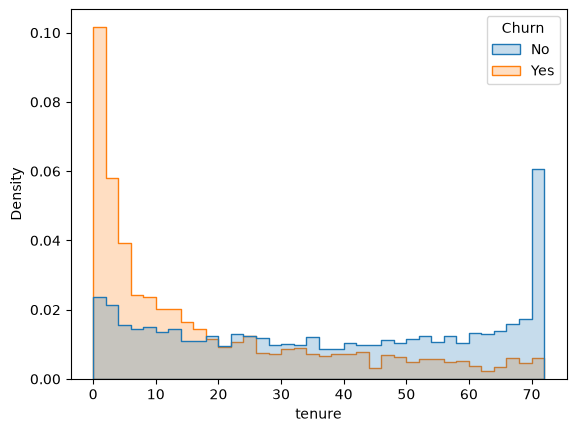

In [72]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=36, stat="density", common_norm=False, element="step")

Chrurning usually happens in the initial part of the `tenure`.

##### Churn-rate curve by month

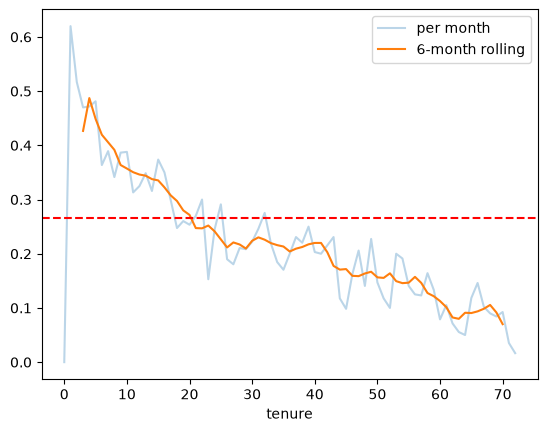

In [73]:
rate = df.groupby("tenure")["Churn_num"].mean()
ax = rate.plot(alpha=0.3, label="per month")
rate.rolling(6, center=True).mean().plot(ax=ax, label="6-month rolling")
ax.axhline(overall, color="red", linestyle="--"); ax.legend()

##### Tenure × Contract: is early churn only a month-to-month effect?

<Axes: xlabel='tenure_band', ylabel='Churn_num'>

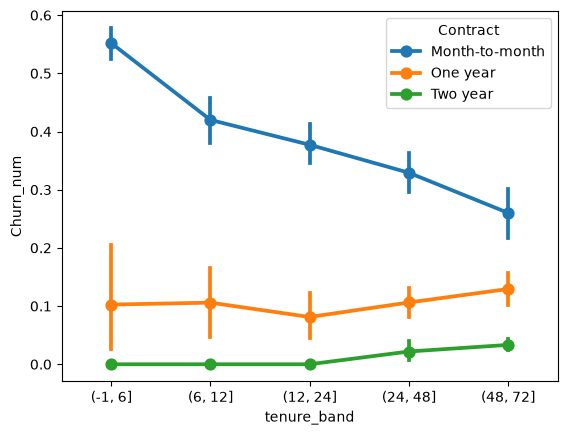

In [74]:
df["tenure_band"] = pd.cut(df["tenure"], [-1, 6, 12, 24, 48, 72])
sns.pointplot(data=df, x="tenure_band", y="Churn_num", hue="Contract")


- If the churn rate drops with tenure within each contract type, tenure has its own effect.
- If the lines are flat, tenure was mostly standing in for contract type.

<Axes: xlabel='Contract', ylabel='tenure'>

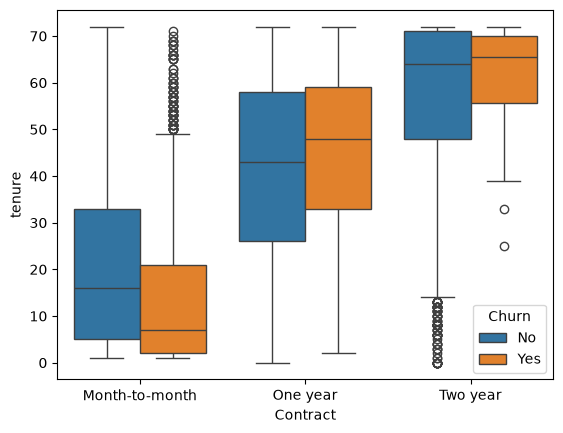

In [75]:
sns.boxplot(data=df, x="Contract", y="tenure", hue="Churn")

##### Check the shape Logistic Regression will see (the most useful step for modelling)
Logistic Regression assumes each extra month changes the `log-odds` of churn by the same amount, which means a straight line on this plot:

<Axes: xlabel='tenure', ylabel='log-odds of churn'>

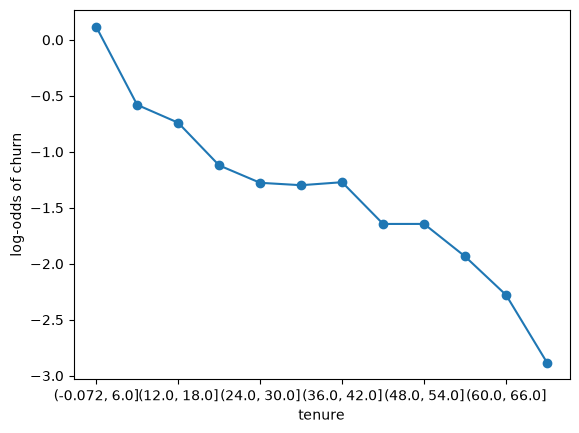

In [77]:
b = df.groupby(pd.cut(df["tenure"], 12), observed=True)["Churn_num"].mean().clip(0.01, 0.99)
np.log(b / (1 - b)).plot(marker="o", ylabel="log-odds of churn")


##### Reading the tenure log-odds plot

**What the plot shows.** Tenure is cut into 12 bins of 6 months. For each bin I take the churn rate *p* and convert it to log-odds, log(p / (1 − p)). Logistic Regression models the log-odds as a straight-line function of each feature: `log-odds = b0 + b1 × tenure`. So if raw `tenure` suits LR, these points should fall roughly on a straight line. Log-odds of 0 means a 50% churn rate, −1.1 is about 25%, and −2.9 is about 5%.

| Tenure (months) | 0–6 | 7–12 | 13–18 | 19–24 | 25–42 | 43–54 | 55–60 | 61–66 | 67–72 |
|---|---|---|---|---|---|---|---|---|---|
| Churn rate | 52.9% | 35.9% | 32.3% | 24.6% | ~21–22% | 16.2% | 12.6% | 9.3% | 5.3% |
| Log-odds | +0.12 | −0.58 | −0.74 | −1.12 | ≈ −1.28 | −1.64 | −1.94 | −2.28 | −2.88 |

**What I see.**
- **Mostly a downward straight line.** A straight line through the 12 points explains about 92% of their variation (R² ≈ 0.92). So raw `tenure` is a reasonable feature for LR.
- **One big kink at the start.** The fall from 0–6 to 7–12 months (+0.12 → −0.58) is much steeper than any later step. The first six months are a distinct high-risk period that a single straight line will under-predict.
- **A flat stretch in the middle** (25–42 months, about 21–22%), then a steeper fall at the end. The last bin includes the pile-up at the 72-month cap, the most loyal long-standing customers.
- **`log1p(tenure)` fits worse** (R² ≈ 0.86). It bends the curve too much: the steep drop is only in the first 6 months, not spread over the first couple of years.

**Tenure overlaps with contract type.** 95% of customers in their first 6 months are on month-to-month contracts, against 15% of those past 4 years. Within month-to-month customers, churn still falls with tenure (55% → 26%), so tenure has its own effect. Within one-year and two-year contracts it stays flat (about 10% and 0–3%). The tenure effect is really a **month-to-month** story.

**Decision for modelling.**
- Logistic Regression: keep raw `tenure` (scaled) and test adding a `tenure_group` feature, or a simple "new customer" flag for tenure ≤ 6, to capture the early kink. Compare them with CV.
- Trees / XGBoost: use raw `tenure` only. Trees find the cut-points themselves, so bins add nothing.
- Caveat: this is a snapshot. For current customers, tenure is "time so far", not total lifetime, so this is not a true survival curve.

## Business insights from the EDA

Baseline churn is **26.5%**. These are associations from a snapshot of customers, not proof of cause, but each one points to a concrete retention action.

**1. Contract type is the biggest single driver of churn.**
Month-to-month customers churn at 42.7%, against 11.3% on one-year and 2.8% on two-year contracts (the strongest association in the data, Theil's U = 0.17). Customers who can leave at any time do. Offering month-to-month customers a discount or perk to move to a one-year contract is likely the highest-impact retention lever.

**2. The first six months are the danger zone.**
Churn is 52.9% among customers in their first 6 months and falls to 9.5% after 4 years; 55% of all churners leave within their first year. The effect is mostly among month-to-month customers (55% → 26% as tenure grows). Onboarding, early check-ins and a "first-year experience" programme should get the retention budget first.

**3. Fibre-optic customers churn far more than DSL customers.**
Fibre customers churn at 41.9% against 19.0% for DSL, and the gap holds at every tenure (e.g. 17% vs 4% even after 4 years). Fibre is the premium product (median monthly charge about \$92 vs \$56 for DSL), which suggests a price-for-value or service-quality problem. This is worth investigating with the product team: pricing, outages and competitor fibre offers.

**4. Electronic-check payers are a high-risk, easy-to-fix group.**
Customers paying by electronic check churn at 45.3%, against 15–19% for the other three methods, and this holds even within month-to-month contracts (53.7% vs 32–34%). Manual payment means a monthly decision point, while autopay removes it. Nudging these customers to automatic payment, for example with a small discount, is a cheap retention action.

**5. Every add-on service makes a customer stickier.**
Among internet customers, churn falls steadily from 54.9% with no add-ons to 5.3% with all five. Online security and tech support matter most: customers without them churn at about 42% against 15% with them. Bundling security or support into offers for at-risk customers both raises the value of the service and ties them in.

**6. One segment holds over 40% of all churners.**
Customers who are month-to-month **and** on fibre **and** paying by electronic check are 1,307 customers (18.6% of the base). They churn at 60.4% and account for 42% of all churners. This is the obvious first target list for a retention campaign, and the model should rank them near the top.

**7. Seniors and single customers churn more, largely through their plan choices.**
Senior citizens churn at 41.7% vs 23.6%, but 71% of them are month-to-month and 52% pay by electronic check, so much of their risk overlaps with insights 1 and 4. Customers without a partner or dependents churn about twice as often as those with a family (34% vs 14%). Family plans and assisted autopay setup for seniors are segment-specific actions; `gender`, by contrast, makes no difference at all.